# Bài toán: Dự đoán xác suất đỗ kỳ thi dựa trên thời gian học
Sử dụng thuật toán **Logistic Sigmoid Regression** để phân loại sinh viên Đỗ (1) và Trượt (0).
Bước đầu tiên, chúng ta sẽ đọc dữ liệu từ file `data_on_thi.csv` và chuẩn bị ma trận đầu vào `X`.

In [3]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2)

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('data4.csv')

# 2. Xây dựng ma trận X và y
# X_raw có kích thước (1, 20)
X_raw = df['Hours'].values.reshape(1, -1)
y = df['Pass'].values

# 3. Mở rộng dữ liệu X (thêm cột toàn số 1 vào đầu để tính bias)
X = np.concatenate((np.ones((1, X_raw.shape[1])), X_raw), axis = 0)

print(f"Kích thước tập dữ liệu X sau khi mở rộng: {X.shape}")

Kích thước tập dữ liệu X sau khi mở rộng: (2, 50)


### Khởi tạo hàm Sigmoid và Thuật toán Gradient Descent
Sử dụng phương pháp **Stochastic Gradient Descent (SGD)**. Ở mỗi vòng lặp, dữ liệu sẽ được xáo trộn ngẫu nhiên để cập nhật vector trọng số `w`.

In [4]:
# Các hàm cần thiết cho logistic sigmoid regression
def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]    
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    
    while count < max_count:
        # mix data         
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            
            # stopping criteria            
            if count%check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

# Chạy thuật toán tìm trọng số w
eta = .05 
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)

print("Trọng số w tối ưu:")
print(w[-1])

Trọng số w tối ưu:
[[-5.3261869 ]
 [ 1.83754721]]


### Trực quan hóa kết quả
Dùng vector trọng số `w` vừa tìm được để tính toán xác suất dự đoán cho tập dữ liệu và vẽ đồ thị Logistic Curve.

Xác suất dự đoán:
[[0.00763915 0.01203993 0.01892757 0.02071126 0.0296372  0.03540399
  0.04612169 0.05988249 0.07110315 0.08423792 0.10808246 0.10808246
  0.11726363 0.13766185 0.16096135 0.1873476  0.23295402 0.24977207
  0.2857586  0.32468607 0.3661976  0.43218742 0.45485957 0.500675
  0.54647911 0.59150959 0.63505482 0.65607275 0.67649684 0.71534227
  0.75123846 0.78397501 0.81347316 0.8397666  0.86297794 0.88329419
  0.9009439  0.92296907 0.92925269 0.94992093 0.95797392 0.96477997
  0.96777205 0.9705177  0.97534459 0.97939798 0.98564303 0.99167657
  0.99518689 0.99666219]]


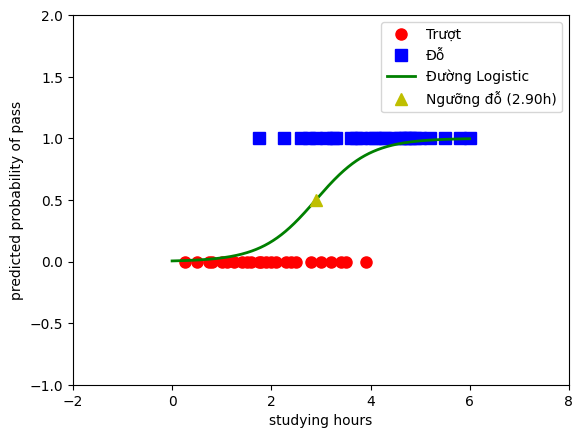

In [5]:
# In xác suất dự đoán
print("Xác suất dự đoán:")
print(sigmoid(np.dot(w[-1].T, X)))

# Biểu diễn kết quả lên đồ thị
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8, label='Trượt')
plt.plot(X1, y1, 'bs', markersize = 8, label='Đỗ')

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)

plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2, label='Đường Logistic')
plt.plot(threshold, .5, 'y^', markersize = 8, label=f'Ngưỡng đỗ ({threshold:.2f}h)')
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.legend()
plt.show()